In [1]:
# Load environment variables and set up auto-reload
import dotenv
import os
from dotenv import load_dotenv
dotenv.load_dotenv("../env_workshop")



%load_ext autoreload
%autoreload 2

# Research Agent 

*Next step in Deep Research is to gather the context collected in the research brief.*

Here is our overall research flow: ![alt text](image-1.png)

Research involves implementing strategies to collect information by synthesizing the request.
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) Agents work well for research because they can try different approaches and use what they learn along the way to decide what to do next.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **Query Generator (LLM)**: Analyzes the research brief and generates web search queries
2. **Web Search Tool**: Executes web search to fetch information based on the search queries. Summarizes information from each page.
3. **Research Compression Node**: Compresses research findings for efficient processing

![alt text](single_tool_call.png)

In [2]:
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")
PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")

In [3]:
from phoenix.otel import register
from openinference.instrumentation import using_metadata
from openinference.instrumentation.langchain import LangChainInstrumentor
from opentelemetry import trace

if os.environ.get("PHOENIX_COLLECTOR_ENDPOINT"):
    # configure the Phoenix tracer
    tracer_provider = register(
    project_name=PHOENIX_PROJECT_NAME, 
    auto_instrument=False 
    )
    LangChainInstrumentor().instrument(tracer_provider=tracer_provider)
else:
    dummy_tracer_provider = NoOpTracerProvider()

tracer = trace.get_tracer(__name__)

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [4]:
from utils import show_prompt
import requests

import os
import sys
from pathlib import Path
from textwrap import dedent
from typing import Any, Dict, List, Literal, Optional
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from langchain_openai import ChatOpenAI

In [18]:
compress_research_system_prompt = """You are a research assistant that has conducted research on a topic by calling several tools and web searches. Your job is now to clean up the findings, but preserve all of the relevant statements and information that the researcher has gathered. For context, today's date is {date}.

<Task>
You need to clean up information gathered from tool calls and web searches in the existing messages.
All relevant information should be repeated and rewritten verbatim, but in a cleaner format.
The purpose of this step is just to remove any obviously irrelevant or duplicate information.
For example, if three sources all say "X", you could say "These three sources all stated X".
Only these fully comprehensive cleaned findings are going to be returned to the user, so it's crucial that you don't lose any information from the raw messages.
</Task>

<Tool Call Filtering>
**IMPORTANT**: When processing the research messages, focus only on substantive research content:
- **Include**: All tavily_search results and findings from web searches
- **Exclude**: think_tool calls and responses - these are internal agent reflections for decision-making and should not be included in the final research report
- **Focus on**: Actual information gathered from external sources, not the agent's internal reasoning process

The think_tool calls contain strategic reflections and decision-making notes that are internal to the research process but do not contain factual information that should be preserved in the final report.
</Tool Call Filtering>

<Guidelines>
1. Your output findings should be fully comprehensive and include ALL of the information and sources that the researcher has gathered from tool calls and web searches. It is expected that you repeat key information verbatim.
2. This report can be as long as necessary to return ALL of the information that the researcher has gathered.
3. In your report, you should return inline citations for each source that the researcher found.
4. You should include a "Sources" section at the end of the report that lists all of the sources the researcher found with corresponding citations, cited against statements in the report.
5. Make sure to include ALL of the sources that the researcher gathered in the report, and how they were used to answer the question!
6. It's really important not to lose any sources. A later LLM will be used to merge this report with others, so having all of the sources is critical.
</Guidelines>

<Output Format>
The report should be structured like this:
**List of Queries and Tool Calls Made**
**Fully Comprehensive Findings**
**List of All Relevant Sources (with citations in the report)**
</Output Format>

<Citation Rules>
- Assign each unique URL a single citation number in your text
- End with ### Sources that lists each source with corresponding numbers
- IMPORTANT: Number sources sequentially without gaps (1,2,3,4...) in the final list regardless of which sources you choose
- Example format:
  [1] Source Title: URL
  [2] Source Title: URL
</Citation Rules>

Critical Reminder: It is extremely important that any information that is even remotely relevant to the user's research topic is preserved verbatim (e.g. don't rewrite it, don't summarize it, don't paraphrase it).
"""

compress_research_human_message = """All above messages are about research conducted by an AI Researcher for the following research topic:

RESEARCH TOPIC: {research_topic}

Your task is to clean up these research findings while preserving ALL information that is relevant to answering this specific research question. 

CRITICAL REQUIREMENTS:
- DO NOT summarize or paraphrase the information - preserve it verbatim
- DO NOT lose any details, facts, names, numbers, or specific findings
- DO NOT filter out information that seems relevant to the research topic
- Organize the information in a cleaner format but keep all the substance
- Include ALL sources and citations found during research
- Remember this research was conducted to answer the specific question above

The cleaned findings will be used for final report generation, so comprehensiveness is critical."""




QUERY_PLANNER_SYSTEM_PROMPT = dedent(
    """
    You are a research query planner. Today's date is {date}.

    Craft up to three specific web search queries that will advance the research task.
    Use recent reflections and search history to avoid duplicate effort, fill knowledge gaps,
    and stay focused on the user's request.

    Return structured output containing:
    - queries: up to three concrete search strings
    - rationale: a concise explanation of how the queries support progress
    - max_results: an integer between 1 and 5 for the Tavily API
    """
)

REFLECTION_SYSTEM_PROMPT = dedent(
    """
    You are a research strategist. Today's date is {date}.

    Evaluate the latest Tavily search observations to decide the next action.
    Provide structured output with:
    - analysis: detailed synthesis of findings (cite sources inline)
    - next_step: "followup" to continue researching or "final" to conclude
    - followup_focus: guidance for the next query plan when continuing
    - final_response: if concluding, the full answer for the user

    Do not invent sources; rely solely on the provided observations and history.
    """
)

### State and Schemas

We'll create the agent state object.
1. **Researcher State**
2. **Researcher Output State**

In [19]:
import operator
from typing import Any, List, Optional

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import Annotated, Literal


class QueryPlanOutput(BaseModel):
    """Structured search plan used by the planner node and stored in state."""

    queries: List[str] = Field(..., min_length=1, max_length=3)
    rationale: str
    max_results: int = Field(3, ge=1, le=5)


class SearchObservationOutput(BaseModel):
    """Captured Tavily search result for later analysis."""

    query: str
    max_results: int = Field(3, ge=1, le=5)
    observation: Any


class ReflectionDecisionOutput(BaseModel):
    """Decision emitted by the reflection node."""

    analysis: str
    next_step: Literal["followup", "final"]
    followup_focus: str = ""
    final_response: str = ""


class PlannerResearchState(BaseModel):
    """State container for the planner-driven research workflow."""

    conversation_history: Annotated[List[BaseMessage], add_messages] = Field(default_factory=list)
    research_topic: Optional[str] = None
    tool_call_iterations: int = 0
    max_tool_calls: int = 20
    compressed_research: Optional[str] = None
    raw_notes: Annotated[List[str], operator.add] = Field(default_factory=list)
    search_events: Annotated[List[SearchObservationOutput], operator.add] = Field(default_factory=list)
    latest_search_observations: List[SearchObservationOutput] = Field(default_factory=list)
    pending_query_plan: Optional[QueryPlanOutput] = None
    query_plan_history: Annotated[List[QueryPlanOutput], operator.add] = Field(default_factory=list)
    latest_reflection_decision: Optional[ReflectionDecisionOutput] = None
    reflection_decisions: Annotated[List[ReflectionDecisionOutput], operator.add] = Field(default_factory=list)

### Web Summarization

We'll create a prompt that will be used to summarize the information from the searched web page.


In [20]:

summarize_webpage_prompt = """
You are an expert at summarizing the web content retrieved from the web search.You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that preserves the important information from the original web page. This summary will be used by a downstream research agent, so it's crucial to maintain the key details without losing essential information.

Here is the raw content of the webpage:

<webpage_content>
{webpage_content}
</webpage_content>

Please follow these guidelines to create your summary:

1. Identify and preserve the main topic or purpose of the webpage.
2. Retain key facts, statistics, and data points that are central to the content's message.
3. Keep important quotes from credible sources or experts.
4. Maintain the chronological order of events if the content is time-sensitive or historical.
5. Preserve any lists or step-by-step instructions if present.
6. Include relevant dates, names, and locations that are crucial to understanding the content.
7. Summarize lengthy explanations while keeping the core message intact.

When handling different types of content:

- For news articles: Focus on the who, what, when, where, why, and how.
- For scientific content: Preserve methodology, results, and conclusions.
- For opinion pieces: Maintain the main arguments and supporting points.
- For product pages: Keep key features, specifications, and unique selling points.

Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information.

Present your summary in the following format:

```
{{
   "summary": "Your summary here, structured with appropriate paragraphs or bullet points as needed",
   "key_excerpts": "First important quote or excerpt, Second important quote or excerpt, Third important quote or excerpt, ...Add more excerpts as needed, up to a maximum of 5"
}}
```

Here are two examples of good summaries:

Example 1 (for a news article):
```json
{{
   "summary": "On July 15, 2023, NASA successfully launched the Artemis II mission from Kennedy Space Center. This marks the first crewed mission to the Moon since Apollo 17 in 1972. The four-person crew, led by Commander Jane Smith, will orbit the Moon for 10 days before returning to Earth. This mission is a crucial step in NASA's plans to establish a permanent human presence on the Moon by 2030.",
   "key_excerpts": "Artemis II represents a new era in space exploration, said NASA Administrator John Doe. The mission will test critical systems for future long-duration stays on the Moon, explained Lead Engineer Sarah Johnson. We're not just going back to the Moon, we're going forward to the Moon, Commander Jane Smith stated during the pre-launch press conference."
}}
```

Example 2 (for a scientific article):
```json
{{
   "summary": "A new study published in Nature Climate Change reveals that global sea levels are rising faster than previously thought. Researchers analyzed satellite data from 1993 to 2022 and found that the rate of sea-level rise has accelerated by 0.08 mm/year² over the past three decades. This acceleration is primarily attributed to melting ice sheets in Greenland and Antarctica. The study projects that if current trends continue, global sea levels could rise by up to 2 meters by 2100, posing significant risks to coastal communities worldwide.",
   "key_excerpts": "Our findings indicate a clear acceleration in sea-level rise, which has significant implications for coastal planning and adaptation strategies, lead author Dr. Emily Brown stated. The rate of ice sheet melt in Greenland and Antarctica has tripled since the 1990s, the study reports. Without immediate and substantial reductions in greenhouse gas emissions, we are looking at potentially catastrophic sea-level rise by the end of this century, warned co-author Professor Michael Green."  
}}
```

Remember, your goal is to create a summary that can be easily understood and utilized by a downstream research agent while preserving the most critical information from the original webpage.

Today's date is {date}.
"""

show_prompt(summarize_webpage_prompt, "Summarize Webpage")

╭─────────────────────────────────────────────── Summarize Webpage ───────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  You are an expert at summarizing the web content retrieved from the web search.You are tasked with             │
│  summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that    │
│  preserves the important information from the original web page. This summary will be used by a downstream      │
│  research agent, so it's crucial to maintain the key details without losing essential information.              │
│                                                                                                                 │
│  Here is the raw content of the webpage:                                                                        │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  Please follow these guidelines to create your summary:                                                         │
│                                                                                                                 │
│  1. Identify and preserve the main topic or purpose of the webpage.                                             │
│  2. Retain key facts, statistics, and data points that are central to the content's message.                    │
│  3. Keep important quotes from credible sources or experts.                                                     │
│  4. Maintain the chronological order of events if the content is time-sensitive or historical.                  │
│  5. Preserve any lists or step-by-step instructions if present.                                                 │
│  6. Include relevant dates, names, and locations that are crucial to understanding the content.                 │
│  7. Summarize lengthy explanations while keeping the core message intact.                                       │
│                                                                                                                 │
│  When handling different types of content:                                                                      │
│                                                                                                                 │
│  - For news articles: Focus on the who, what, when, where, why, and how.                                        │
│  - For scientific content: Preserve methodology, results, and conclusions.                                      │
│  - For opinion pieces: Maintain the main arguments and supporting points.                                       │
│  - For product pages: Keep key features, specifications, and unique selling points.                             │
│                                                                                                                 │
│  Your summary should be significantly shorter than the original content but comprehensive enough to stand       │
│  alone as a source of information.                                                                              │
│                                                                                                                 │
│  Present your summary in the following format:        

## Helper Utility Functions 

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing


In [21]:

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from langchain_openai import ChatOpenAI

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = ChatOpenAI(
    model="gpt-4.1-mini",
    base_url=OPENAI_BASE_URL,
)

#tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

TAVILY_BASE_URL = os.environ.get("TAVILY_BASE_URL")
def tavily_search_helper(query, **kw):
    r = requests.post(TAVILY_BASE_URL,
                      json={"query": query, **kw}, timeout=180)
    r.raise_for_status()
    return r.json()

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_search_helper(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output



In [27]:
query_planner_model = ChatOpenAI(
    model="gpt-4.1-mini",
    base_url=OPENAI_BASE_URL,
).with_structured_output(QueryPlanOutput)

reflection_model = ChatOpenAI(
    model="gpt-4.1-mini",
    base_url=OPENAI_BASE_URL,
).with_structured_output(ReflectionDecisionOutput)

compress_model = ChatOpenAI(
    model="gpt-4.1",
    base_url=OPENAI_BASE_URL,
    max_tokens=32000,
)

### Tools

#### Tavily SDK Integration
**tavily search tool**: Tool to perform web searches.
We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance


In [28]:
# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization

#### 2. Research Result Compression  

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [29]:
??ToolNode

Object `ToolNode` not found.


In [30]:
def _summarize_search_history(search_events: List[SearchObservationOutput], limit: int = 3) -> str:
    if not search_events:
        return "No prior searches have been executed."

    recent = search_events[-limit:]
    lines: List[str] = []
    for idx, event in enumerate(recent, start=1):
        snippet = event.observation
        if isinstance(snippet, str) and len(snippet) > 500:
            snippet = snippet[:500] + "..."
        lines.append(
            f"[{idx}] query='{event.query}'\n    snippet: {snippet}"
        )
    return "\n".join(lines)


# ===== AGENT NODES =====

def generate_queries(state: PlannerResearchState) -> Dict[str, Any]:
    """Node 1: propose Tavily query plan via structured LLM output."""

    search_history = _summarize_search_history(state.search_events)
    latest_reflection: Optional[ReflectionDecisionOutput] = state.latest_reflection_decision
    followup_focus = ""
    if (
        latest_reflection
        and latest_reflection.next_step == "followup"
        and latest_reflection.followup_focus
    ):
        followup_focus = latest_reflection.followup_focus

    system_prompt = QUERY_PLANNER_SYSTEM_PROMPT.format(date=get_today_str())
    messages: List[BaseMessage] = [SystemMessage(content=system_prompt)]

    context_sections: List[str] = ["=== Research Request ==="]
    if state.research_topic:
        context_sections.append(state.research_topic)
    if followup_focus:
        context_sections.append("=== Follow-up Focus ===")
        context_sections.append(followup_focus)
    if latest_reflection:
        context_sections.append("=== Latest Reflection Summary ===")
        context_sections.append(
            (
                f"Analysis: {latest_reflection.analysis}\n"
                f"Prior next step: {latest_reflection.next_step}\n"
                f"Suggested focus: {latest_reflection.followup_focus or 'None'}"
            )
        )
    context_sections.append("=== Recent Search History ===")
    context_sections.append(search_history)

    messages.append(HumanMessage(content="\n".join(context_sections)))

    plan = query_planner_model.invoke(messages)

    return {
        "pending_query_plan": plan,
        "query_plan_history": [plan],
    }


def search_web(state: PlannerResearchState) -> Dict[str, Any]:
    """Node 2: execute Tavily searches for the planned queries."""

    if not state.pending_query_plan:
        raise ValueError("No pending query plan available for execution.")

    plan = state.pending_query_plan

    search_events: List[SearchObservationOutput] = []

    for query in plan.queries:
        observation = tavily_search.invoke(
            {"query": query},
            config={
                "configurable": {
                    "max_results": plan.max_results,
                }
            },
        )
        search_events.append(
            SearchObservationOutput(
                query=query,
                max_results=plan.max_results,
                observation=observation,
            )
        )

    return {
        "tool_call_iterations": state.tool_call_iterations + len(search_events),
        "search_events": search_events,
        "latest_search_observations": search_events,
        "pending_query_plan": None,
    }


def reflect_and_decide(state: PlannerResearchState) -> Dict[str, Any]:
    """Node 3: reflect on findings and return next step."""

    observations: List[SearchObservationOutput] = state.latest_search_observations or state.search_events
    if not observations:
        raise ValueError("Reflection requires recent search observations.")

    observation_chunks: List[str] = []
    for event in observations:
        snippet = event.observation
        if isinstance(snippet, str) and len(snippet) > 800:
            snippet = snippet[:800] + "..."
        observation_chunks.append(
            f"Query: {event.query}\nResults: {snippet}"
        )

    system_prompt = REFLECTION_SYSTEM_PROMPT.format(date=get_today_str())
    messages: List[BaseMessage] = [SystemMessage(content=system_prompt)]

    context_sections: List[str] = []
    if state.research_topic:
        context_sections.extend([
            "=== Research Request ===",
            state.research_topic,
        ])
    if state.latest_reflection_decision and state.latest_reflection_decision.followup_focus:
        context_sections.extend([
            "=== Active Focus ===",
            state.latest_reflection_decision.followup_focus,
        ])
    context_sections.extend([
        "=== Latest Tavily Observations ===",
        "\n\n".join(observation_chunks),
    ])

    messages.append(HumanMessage(content="\n\n".join(context_sections)))

    decision = reflection_model.invoke(messages)
    if decision.next_step == "final" and not decision.final_response:
        raise ValueError("Reflection indicated 'final' but did not provide a final response.")

    return {
        "latest_reflection_decision": decision,
        "reflection_decisions": [decision],
        "latest_search_observations": list(observations),
    }




def compress_research(state: PlannerResearchState) -> Dict[str, Any]:
    """Compress research findings while maintaining source fidelity."""

    system_message = compress_research_system_prompt.format(date=get_today_str())
    notes_sections: List[str] = []

    if state.research_topic:
        notes_sections.extend([
            "=== Research Request ===",
            state.research_topic,
        ])

    query_plan_history: List[QueryPlanOutput] = state.query_plan_history or []
    if query_plan_history:
        plan_lines: List[str] = []
        for idx, plan in enumerate(query_plan_history[-5:], start=1):
            plan_lines.append(
                f"[{idx}] queries={plan.queries} | rationale={plan.rationale}"
            )
        notes_sections.extend([
            "=== Query Plans ===",
            "\n".join(plan_lines),
        ])

    search_events: List[SearchObservationOutput] = state.search_events or []
    if search_events:
        event_lines: List[str] = []
        for idx, event in enumerate(search_events, start=1):
            snippet = event.observation
            if isinstance(snippet, str) and len(snippet) > 600:
                snippet = snippet[:600] + "..."
            event_lines.append(
                f"[{idx}] query='{event.query}'\n    results: {snippet}"
            )
        notes_sections.extend([
            "=== Search Observations ===",
            "\n".join(event_lines),
        ])

    reflection_decisions: List[ReflectionDecisionOutput] = state.reflection_decisions or []
    if reflection_decisions:
        decision_lines: List[str] = []
        for idx, decision in enumerate(reflection_decisions, start=1):
            analysis = decision.analysis
            if isinstance(analysis, str) and len(analysis) > 600:
                analysis = analysis[:600] + "..."
            decision_lines.append(
                f"[{idx}] analysis={analysis}\n    next_step={decision.next_step} | focus={decision.followup_focus}"
            )
        notes_sections.extend([
            "=== Reflection Summaries ===",
            "\n".join(decision_lines),
        ])

    if state.latest_reflection_decision and state.latest_reflection_decision.final_response:
        notes_sections.extend([
            "=== Final Draft Response ===",
            state.latest_reflection_decision.final_response,
        ])

    notes_body = "\n\n".join(notes_sections) if notes_sections else "No research notes captured."

    human_prompt = "\n\n".join(
        [
            notes_body,
            "=== Compression Instruction ===",
            compress_research_human_message,
        ]
    )

    messages: List[BaseMessage] = [
        SystemMessage(content=system_message),
        HumanMessage(content=human_prompt),
    ]

    response = compress_model.invoke(messages)

    return {
        "compressed_research": str(response.content),
        "raw_notes": [notes_body],
    }


# ===== ROUTING LOGIC =====

def next_step_after_reflection(state: PlannerResearchState) -> Literal["generate_queries", "compress_research"]:
    decision = state.latest_reflection_decision
    if not decision:
        raise ValueError("Reflection decision missing from state; cannot determine next step.")


    if state.tool_call_iterations > state.max_tool_calls:
        return "compress_research"

    if decision.next_step == "followup" :
        return "generate_queries"

    if decision.next_step == "final":
        return "compress_research"
    raise ValueError("Reflection must set next_step to 'followup' or 'final'.")



# ===== GRAPH CONSTRUCTION =====

agent_builder = StateGraph(PlannerResearchState)


agent_builder.add_node("generate_queries", generate_queries)
agent_builder.add_node("search_web", search_web)
agent_builder.add_node("reflect", reflect_and_decide)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "generate_queries")
agent_builder.add_edge("generate_queries", "search_web")
agent_builder.add_edge("search_web", "reflect")
agent_builder.add_conditional_edges(
    "reflect",
    next_step_after_reflection,
    {
        "generate_queries": "generate_queries",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("compress_research", END)

researcher_agent = agent_builder.compile()

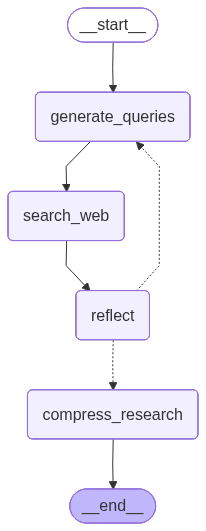

In [31]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""


with tracer.start_as_current_span("tool_search"):
    result = researcher_agent_new.invoke({"research_topic": research_brief})
    
format_messages(result['researcher_messages'])

Failed to summarize webpage: name 'Summary' is not defined
Failed to summarize webpage: name 'Summary' is not defined
Failed to summarize webpage: name 'Summary' is not defined


KeyboardInterrupt: 

In [ ]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])